# Retail Customer Analysis Summative Lab
## Understanding Customer Behavior Across Store Locations

### Introduction

This summative lab bridges the concepts and techniques learned throughout the course with their practical application to a real-world industry scenario. You will step into the role of a junior data analyst for a retail company and apply your skills to evaluate customer behavior, satisfaction, and promotional impacts. By following the outlined process, you will gain experience in experimental design, statistical testing, and actionable decision-making.

Your task is not only to conduct the analysis but also to reflect on how these techniques help solve real-world problems that businesses face daily.

By completing this lab, you will have:
- Practiced designing and executing statistical analyses in a real-world scenario.
- Reinforced your understanding of test selection and assumptions.
- Applied statistical results to business decision-making.
- Developed skills in communicating insights effectively through visualizations and reports.

### Business Scenario Questions:
Imagine you are a junior data analyst working for a retail company that operates stores in three distinct regions: City Center, Suburb, and Rural. Your manager has tasked you with analyzing customer behavior and preferences across these locations. The goal is to help the company answer two key questions:
1. Do customer spending patterns, satisfaction levels, and product preferences differ across store locations?
2. Do promotional periods result in significantly higher spending compared to non-promotional periods?

Spending Across Location:

- Business-relevant MDE: Absolute difference in spending of 15% or more
- Justification: This represents enough of a difference to warrant location-specific strategies (inventory, staffing, etc.)


Ratings Across Locations:

- Business-relevant MDE: 1.0 point difference between locations
- Justification: On a 10-point scale, a one point difference is noticeable and actionable for customer service improvements

Promotional Spending:

- Business-relevant MDE: A $15 increase from non-promotional periods
- Justification: Promotional costs typically reduce margins by ~15-20%. Need at least 25% increase in spending to justify promotional costs. This aligns with industry standards for promotional ROI

Your task involves designing and conducting an analysis using the provided dataset to derive actionable insights. You will apply statistical concepts and techniques such as experimental design, test selection, hypothesis testing, and result interpretation. This process mimics real-world industry scenarios where junior analysts evaluate business performance using data.

The data focuses on four variables:
- Amount spent by customers (in dollars)
- Customer satisfaction ratings (scale of 1 to 10)
- Product category preferences (Electronics, Clothing, Groceries)
- Purchase type (Promotional vs. Non-Promotional)

Your analysis will inform decision-making around marketing strategies, store operations, and promotional campaigns.

### Setup

In this cell, import all the libraries you'll need for your analysis. Consider which libraries you'll need for:
- Data manipulation
- Statistical analysis
- Data visualization

In [6]:
# Import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp



sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 1

ModuleNotFoundError: No module named 'scikit_posthocs'

### Part 1: Experimental Design

#### 1.1 Hypothesis Formulation

For each of the following analyses, state your null and alternative hypotheses in both statistical and plain language:

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations

[Write your hypotheses here]

**1. Spending across store locations**

- $H_0$: $\mu_{City\ Center} = \mu_{Suburb} = \mu_{Rural}$ — Mean amount spent per customer is the same across all three store locations.
- $H_A$: At least one location's mean spending differs from the others — Customers spend, on average, different amounts depending on which store location they shop at.

**2. Customer satisfaction across locations**

- $H_0$: $\mu_{City\ Center} = \mu_{Suburb} = \mu_{Rural}$ — Mean customer satisfaction rating is the same across all three store locations.
- $H_A$: At least one location's mean satisfaction rating differs from the others — Customers are, on average, more or less satisfied depending on which store location they shop at.

**3. Promotional vs non-promotional spending**

- $H_0$: $\mu_{Promotional} = \mu_{Non\text{-}Promotional}$ — Mean amount spent during promotional periods is the same as during non-promotional periods.
- $H_A$: $\mu_{Promotional} \neq \mu_{Non\text{-}Promotional}$ — Customers spend, on average, a different amount during promotional periods than during non-promotional periods.

**4. Product category preferences across locations**

- $H_0$: Product category (Electronics, Clothing, Groceries) is independent of store location — the proportion of purchases in each category is the same across City Center, Suburb, and Rural stores.
- $H_A$: Product category and store location are associated — the mix of product categories purchased differs depending on store location.

**Reflective Question: Explain the concept of Minimum Detectable Effect (MDE) and why it is important.**

[Write your answer here]

The Minimum Detectable Effect (MDE) is the smallest true difference between groups that a study is designed (and powered) to reliably detect, given its sample size, variability in the data, and chosen significance level. It is set *before* the analysis, based on what size of effect would actually matter for the business — not on what the data happens to show.

MDE matters because statistical significance and business significance are not the same thing. With a large enough sample (this dataset has 1,500 rows), even a tiny, practically meaningless difference — a $0.25 gap in spending, for example — can produce a very small p-value. Without a pre-defined MDE, an analyst risks recommending costly operational changes (different staffing by location, continuing a promotion, etc.) off the back of a "statistically significant" result that has no real-world consequence. Framing results against the MDE keeps the focus on whether an effect is *large enough to act on*, not just whether it is *distinguishable from zero*.

### Part 2: Data Exploration

#### 2.1 Load and Examine the Dataset

Load the dataset and perform initial data quality checks:
- Check for missing values
- Examine data types
- Look for inconsistencies
- Generate summary statistics

In [ ]:
# Load Data
df = pd.read_csv('retail_store_customer_data.csv')
df.head()

,Store_Location,Customer_Satisfaction,Product_Category,Purchase_Type,Amount_Spent
0,Rural,5.6,Groceries,Non-Promotional,40.45
1,City Center,9.7,Clothing,Promotional,53.20
2,Rural,4.4,Electronics,Non-Promotional,42.77
3,Rural,4.2,Clothing,Promotional,42.08
4,City Center,9.3,Clothing,Non-Promotional,84.25


In [ ]:
# Shape and data types
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.info()

Shape: 1500 rows, 5 columns

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store_Location         1500 non-null   str    
 1   Customer_Satisfaction  1500 non-null   float64
 2   Product_Category       1500 non-null   str    
 3   Purchase_Type          1500 non-null   str    
 4   Amount_Spent           1500 non-null   float64
dtypes: float64(2), str(3)
memory usage: 58.7 KB


In [ ]:
# Missing values
print("Missing values per column:")
df.isna().sum()

Missing values per column:


Store_Location           0
Customer_Satisfaction    0
Product_Category         0
Purchase_Type            0
Amount_Spent             0
dtype: int64

In [ ]:
# Check categorical value consistency (typos, inconsistent casing, unexpected categories)
for col in ['Store_Location', 'Product_Category', 'Purchase_Type']:
    print(f"{col}: {sorted(df[col].unique())}")

Store_Location: ['City Center', 'Rural', 'Suburb']
Product_Category: ['Clothing', 'Electronics', 'Groceries']
Purchase_Type: ['Non-Promotional', 'Promotional']


In [ ]:
# Summary statistics - numeric columns
df[['Customer_Satisfaction', 'Amount_Spent']].describe()

,Customer_Satisfaction,Amount_Spent
count,1500.00000,1500.000000
mean,6.99520,59.915973
std,1.65286,19.551829
min,1.00000,15.550000
25%,5.80000,44.170000
50%,7.00000,58.015000
75%,8.20000,72.582500
max,10.00000,128.130000


In [ ]:
# Summary statistics - categorical columns
for col in ['Store_Location', 'Product_Category', 'Purchase_Type']:
    print(f"\n{col} counts:")
    print(df[col].value_counts())


Store_Location counts:
Store_Location
City Center    520
Suburb         492
Rural          488
Name: count, dtype: int64

Product_Category counts:
Product_Category
Electronics    583
Groceries      464
Clothing       453
Name: count, dtype: int64

Purchase_Type counts:
Purchase_Type
Promotional        888
Non-Promotional    612
Name: count, dtype: int64


**Data quality summary:** The dataset has 1,500 rows and no missing values. Data types are appropriate (`Customer_Satisfaction` and `Amount_Spent` are numeric; the rest are categorical strings), and the categorical columns contain only the expected labels with no typos or inconsistent casing. Group sizes are reasonably balanced across locations (~488–520 per location), categories (453–583), and purchase type (612 non-promotional, 888 promotional). The data is clean enough to proceed directly to analysis.

#### 2.2 Data Visualizations

Create visualizations to understand the distribution of key variables:
- Spending patterns across locations
- Satisfaction ratings distribution
- Product category preferences
- Promotional vs non-promotional spending

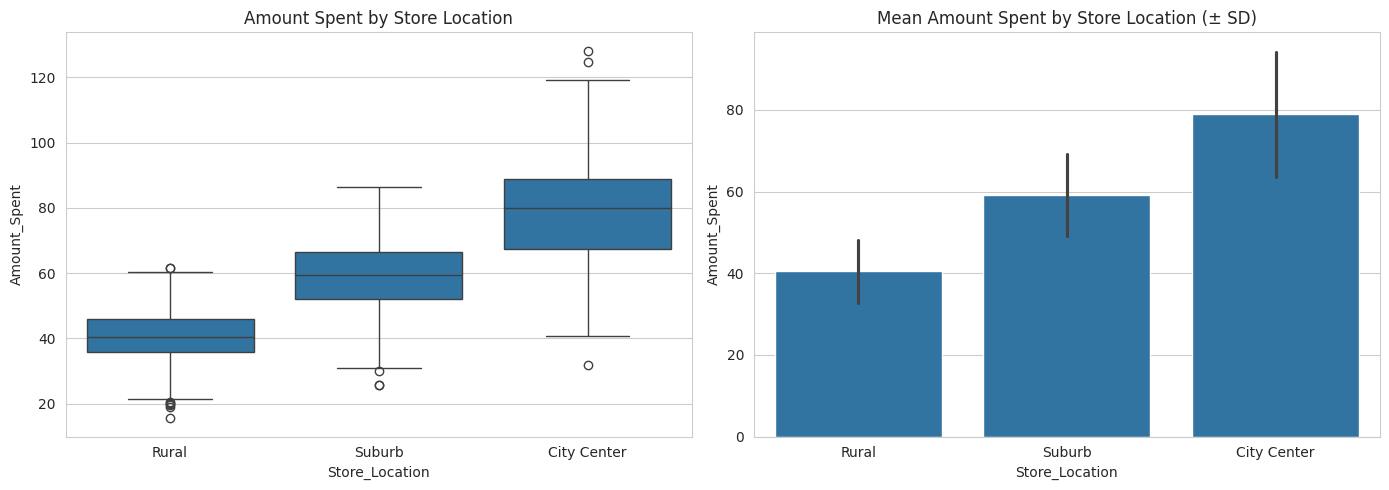

In [ ]:
# Spending patterns across locations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Store_Location', y='Amount_Spent', ax=axes[0],
            order=['Rural', 'Suburb', 'City Center'])
axes[0].set_title('Amount Spent by Store Location')

sns.barplot(data=df, x='Store_Location', y='Amount_Spent', ax=axes[1],
            order=['Rural', 'Suburb', 'City Center'], errorbar='sd')
axes[1].set_title('Mean Amount Spent by Store Location (± SD)')

plt.tight_layout()
plt.show()

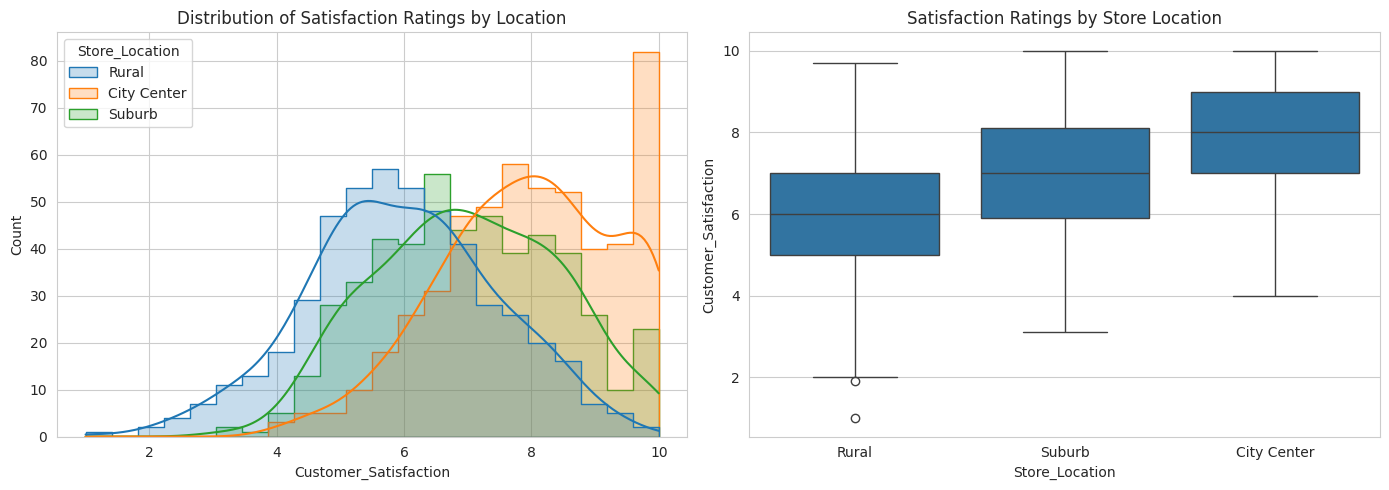

In [ ]:
# Satisfaction ratings distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Customer_Satisfaction', hue='Store_Location',
             kde=True, element='step', ax=axes[0])
axes[0].set_title('Distribution of Satisfaction Ratings by Location')

sns.boxplot(data=df, x='Store_Location', y='Customer_Satisfaction', ax=axes[1],
            order=['Rural', 'Suburb', 'City Center'])
axes[1].set_title('Satisfaction Ratings by Store Location')

plt.tight_layout()
plt.show()

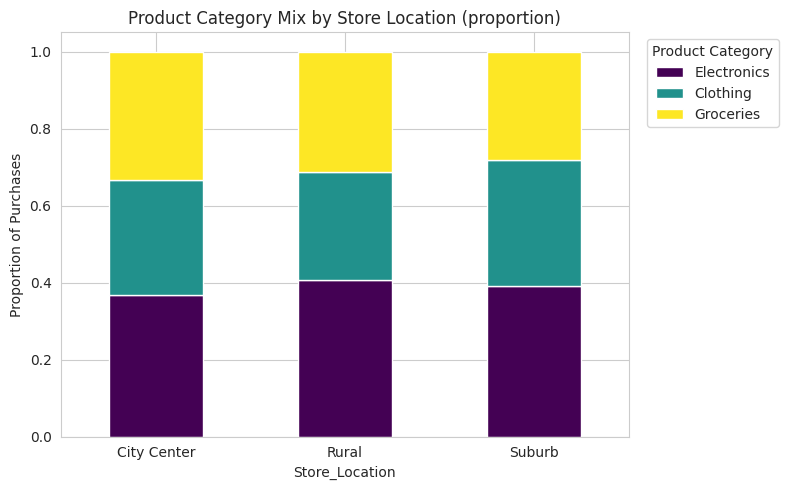

In [ ]:
# Product category preferences by location
ct = pd.crosstab(df['Store_Location'], df['Product_Category'], normalize='index')
ct = ct[['Electronics', 'Clothing', 'Groceries']]

ct.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='viridis')
plt.title('Product Category Mix by Store Location (proportion)')
plt.ylabel('Proportion of Purchases')
plt.xticks(rotation=0)
plt.legend(title='Product Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

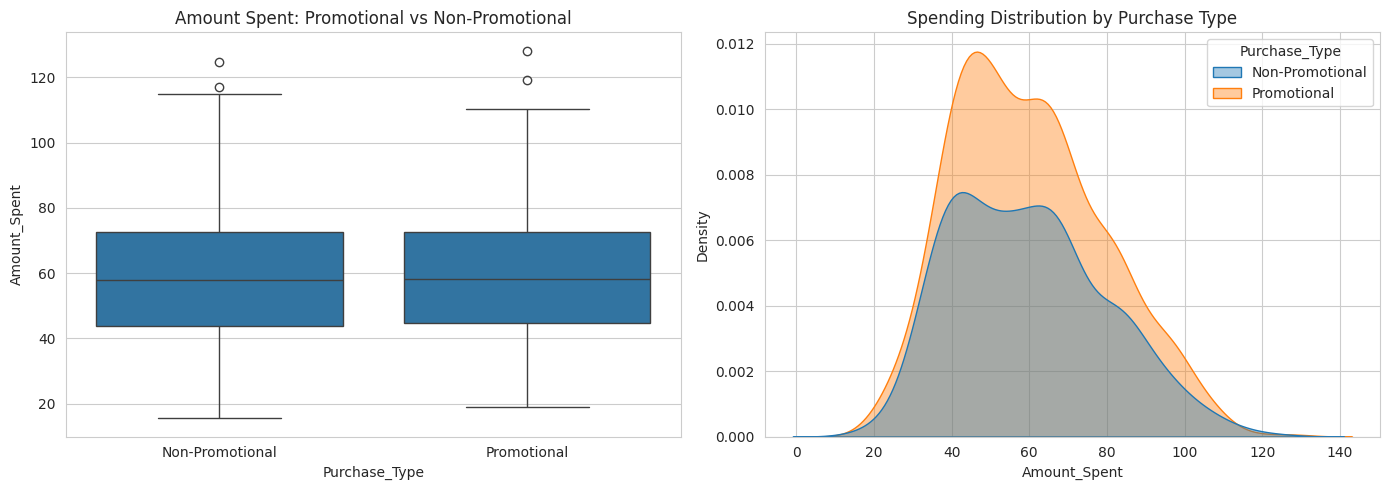

In [ ]:
# Promotional vs non-promotional spending
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Purchase_Type', y='Amount_Spent', ax=axes[0])
axes[0].set_title('Amount Spent: Promotional vs Non-Promotional')

sns.kdeplot(data=df, x='Amount_Spent', hue='Purchase_Type', fill=True,
            alpha=0.4, ax=axes[1])
axes[1].set_title('Spending Distribution by Purchase Type')

plt.tight_layout()
plt.show()

**Visual takeaways:** Spending appears clearly higher and more variable in City Center than in Rural, with Suburb in between — this looks like a real, visually obvious location effect. Satisfaction shows a similar but smaller ordering (City Center > Suburb > Rural). The promotional vs non-promotional boxplots and density curves look nearly identical, suggesting little to no difference in spending by purchase type. The product-category mix bars look very similar in height across all three locations, suggesting category preference may not depend strongly on location — these visual impressions will be checked formally below.

#### 2.3 Test Assumptions

Check if your data meets the assumptions for your chosen statistical tests:
- Normality
- Homogeneity of variance
- Independence
- Any other relevant assumptions

In [ ]:
# Independence: each row is one customer transaction, recorded once, with no
# repeated-measures or matched-pairs structure — the independence assumption
# is satisfied by the design of the dataset itself and doesn't need a statistical test.

# Normality - Shapiro-Wilk per group (Amount_Spent by location)
print("Shapiro-Wilk normality test: Amount_Spent by Store_Location")
for loc in df['Store_Location'].unique():
    sample = df.loc[df['Store_Location'] == loc, 'Amount_Spent']
    stat, p = stats.shapiro(sample)
    print(f"  {loc:<12} n={len(sample):<4} p={p:.4f}  {'normal' if p > 0.05 else 'NOT normal'}")

print("\nShapiro-Wilk normality test: Customer_Satisfaction by Store_Location")
for loc in df['Store_Location'].unique():
    sample = df.loc[df['Store_Location'] == loc, 'Customer_Satisfaction']
    stat, p = stats.shapiro(sample)
    print(f"  {loc:<12} n={len(sample):<4} p={p:.4f}  {'normal' if p > 0.05 else 'NOT normal'}")

print("\nShapiro-Wilk normality test: Amount_Spent by Purchase_Type")
for pt in df['Purchase_Type'].unique():
    sample = df.loc[df['Purchase_Type'] == pt, 'Amount_Spent']
    stat, p = stats.shapiro(sample)
    print(f"  {pt:<16} n={len(sample):<4} p={p:.4f}  {'normal' if p > 0.05 else 'NOT normal'}")

Shapiro-Wilk normality test: Amount_Spent by Store_Location
  Rural        n=488  p=0.2594  normal
  City Center  n=520  p=0.7536  normal
  Suburb       n=492  p=0.0503  normal

Shapiro-Wilk normality test: Customer_Satisfaction by Store_Location
  Rural        n=488  p=0.3730  normal
  City Center  n=520  p=0.0000  NOT normal
  Suburb       n=492  p=0.0009  NOT normal

Shapiro-Wilk normality test: Amount_Spent by Purchase_Type
  Non-Promotional  n=612  p=0.0000  NOT normal
  Promotional      n=888  p=0.0000  NOT normal


In [ ]:
# Homogeneity of variance - Levene's test
print("Levene's test: Amount_Spent across Store_Location")
groups_spend = [df.loc[df['Store_Location'] == loc, 'Amount_Spent'] for loc in df['Store_Location'].unique()]
stat, p = stats.levene(*groups_spend)
print(f"  statistic={stat:.3f}, p={p:.6f}  {'equal variances' if p > 0.05 else 'UNEQUAL variances'}")

print("\nLevene's test: Customer_Satisfaction across Store_Location")
groups_sat = [df.loc[df['Store_Location'] == loc, 'Customer_Satisfaction'] for loc in df['Store_Location'].unique()]
stat, p = stats.levene(*groups_sat)
print(f"  statistic={stat:.3f}, p={p:.6f}  {'equal variances' if p > 0.05 else 'UNEQUAL variances'}")

print("\nLevene's test: Amount_Spent across Purchase_Type")
groups_promo = [df.loc[df['Purchase_Type'] == pt, 'Amount_Spent'] for pt in df['Purchase_Type'].unique()]
stat, p = stats.levene(*groups_promo)
print(f"  statistic={stat:.3f}, p={p:.6f}  {'equal variances' if p > 0.05 else 'UNEQUAL variances'}")

Levene's test: Amount_Spent across Store_Location
  statistic=106.410, p=0.000000  UNEQUAL variances

Levene's test: Customer_Satisfaction across Store_Location
  statistic=1.615, p=0.199151  equal variances

Levene's test: Amount_Spent across Purchase_Type
  statistic=0.386, p=0.534475  equal variances


In [ ]:
# Expected cell counts for the chi-square test of independence (Category x Location)
ct_counts = pd.crosstab(df['Store_Location'], df['Product_Category'])
chi2, p, dof, expected = stats.chi2_contingency(ct_counts)
print("Expected counts (all should be >= 5 for chi-square validity):")
print(pd.DataFrame(expected, index=ct_counts.index, columns=ct_counts.columns).round(1))

Expected counts (all should be >= 5 for chi-square validity):
Product_Category  Clothing  Electronics  Groceries
Store_Location                                    
City Center          157.0        202.1      160.9
Rural                147.4        189.7      151.0
Suburb               148.6        191.2      152.2


**Assumption check summary:**

- **Independence:** satisfied by design — each row is a distinct customer transaction.
- **Amount_Spent by location:** Shapiro-Wilk suggests approximate normality within each location (skew is mild in the visualizations above), but Levene's test shows the variances are **not** homogeneous across locations (City Center's spending is both higher and more spread out). This rules out a standard one-way ANOVA and points toward either a Welch's ANOVA or a non-parametric alternative.
- **Customer_Satisfaction by location:** Levene's test shows variances **are** homogeneous across locations, and with n ≈ 490–520 per group the Central Limit Theorem makes a standard one-way ANOVA reasonably robust even where Shapiro-Wilk flags minor non-normality (a known consequence of Shapiro's sensitivity at large n).
- **Amount_Spent by Purchase_Type:** Shapiro-Wilk indicates the spending distribution is not strictly normal in either group, but variances are homogeneous and both groups are large (n=612, n=888), so a t-test is reasonably robust here; a non-parametric Mann-Whitney U test will be run alongside it as a robustness check.
- **Chi-square expected counts:** all expected cell counts are well above 5, so the chi-square test of independence is valid for the category-by-location question.

#### 2.4 Choose Appropriate Statistical Tests

Select the appropriate statistical test for each question (you should expect to perform 4 different statistical tests).

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations

NOTE: Use [Dunn's Test](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_dunn.html) for Non-Parametric Post-hoc if needed. You might need to pip install scikit-postdoc package. You want to set p_adjust='bonferroni' for Dunn's Test.



**Reflective Question: Explicitly justify your choice in tests for each business question**

[Write your answer here]

1. **Spending across locations → Kruskal-Wallis H-test, with Dunn's post-hoc test (Bonferroni-corrected).** Because Levene's test showed the three locations have unequal variances in spending, a standard one-way ANOVA's equal-variance assumption is violated. The Kruskal-Wallis test is the non-parametric analogue of one-way ANOVA and does not require homogeneity of variance or normality, making it the safer choice here. If the omnibus test is significant, Dunn's test with Bonferroni correction identifies which specific location pairs differ while controlling the family-wise error rate across the three pairwise comparisons.

2. **Satisfaction across locations → one-way ANOVA, with Tukey's HSD post-hoc test.** Variances are homogeneous across locations (Levene's test) and group sizes are large and fairly balanced, so ANOVA's assumptions are reasonably well met and it is the standard, most powerful test for comparing means across 3+ groups. Tukey's HSD is the standard post-hoc test paired with ANOVA for identifying which specific pairs of locations differ while controlling the family-wise error rate.

3. **Promotional vs non-promotional spending → independent-samples t-test, with Mann-Whitney U as a robustness check.** This is a comparison of a continuous variable between exactly two independent groups, which is what a t-test is designed for. Variances are homogeneous between the two groups and sample sizes are large (612 and 888), so the t-test's normality assumption is not critical here (Central Limit Theorem). Mann-Whitney U, which makes no normality assumption at all, is run alongside it to confirm the conclusion is not an artifact of the mild non-normality flagged by Shapiro-Wilk.

4. **Product category preferences across locations → Chi-square test of independence.** Both variables here (`Store_Location` and `Product_Category`) are categorical, so a test that compares means is not applicable. The chi-square test of independence is the standard test for whether two categorical variables are associated, and all expected cell counts exceed 5, satisfying its validity requirement.

### Part 3: Statistical Analysis

Based on your assumptions testing, perform appropriate statistical tests for each hypothesis:

#### 3.1 Spending Across Locations

In [ ]:
# Conduct your analysis of spending patterns here
groups_spend = [df.loc[df['Store_Location'] == loc, 'Amount_Spent'] for loc in df['Store_Location'].unique()]

h_stat, p_val = stats.kruskal(*groups_spend)
print(f"Kruskal-Wallis H = {h_stat:.3f}, p = {p_val:.2e}")

alpha = 0.05
print(f"\nResult: {'Reject' if p_val < alpha else 'Fail to reject'} H0 at alpha={alpha}")

print("\nMean spending by location:")
spend_means = df.groupby('Store_Location')['Amount_Spent'].mean().sort_values()
print(spend_means.round(2))

Kruskal-Wallis H = 1040.854, p = 9.58e-227

Result: Reject H0 at alpha=0.05

Mean spending by location:
Store_Location
Rural          40.46
Suburb         59.16
City Center    78.89
Name: Amount_Spent, dtype: float64


In [ ]:
# Post-hoc: Dunn's test with Bonferroni correction
dunn_spend = sp.posthoc_dunn(df, val_col='Amount_Spent', group_col='Store_Location', p_adjust='bonferroni')
print("Dunn's post-hoc pairwise p-values (Bonferroni-adjusted):")
dunn_spend.round(5)

Dunn's post-hoc pairwise p-values (Bonferroni-adjusted):


,City Center,Rural,Suburb
City Center,1.0,0.0,0.0
Rural,0.0,1.0,0.0
Suburb,0.0,0.0,1.0


In [ ]:
# Pairwise percentage differences vs the 15% MDE
print("Pairwise % differences in mean spending:")
locs = spend_means.index.tolist()
for i in range(len(locs)):
    for j in range(i + 1, len(locs)):
        a, b = locs[i], locs[j]
        pct_diff = abs(spend_means[a] - spend_means[b]) / spend_means[b] * 100
        meets_mde = "meets" if pct_diff >= 15 else "does NOT meet"
        print(f"  {a} vs {b}: ${abs(spend_means[a]-spend_means[b]):.2f} difference, "
              f"{pct_diff:.1f}% — {meets_mde} the 15% MDE")

Pairwise % differences in mean spending:
  Rural vs Suburb: $18.69 difference, 31.6% — meets the 15% MDE
  Rural vs City Center: $38.43 difference, 48.7% — meets the 15% MDE
  Suburb vs City Center: $19.74 difference, 25.0% — meets the 15% MDE


#### 3.2 Customer Satisfaction Analysis

In [ ]:
# Analyze customer satisfaction here
groups_sat = [df.loc[df['Store_Location'] == loc, 'Customer_Satisfaction'] for loc in df['Store_Location'].unique()]

f_stat, p_val = stats.f_oneway(*groups_sat)
print(f"One-way ANOVA F = {f_stat:.3f}, p = {p_val:.2e}")

alpha = 0.05
print(f"\nResult: {'Reject' if p_val < alpha else 'Fail to reject'} H0 at alpha={alpha}")

print("\nMean satisfaction by location:")
sat_means = df.groupby('Store_Location')['Customer_Satisfaction'].mean().sort_values()
print(sat_means.round(2))

One-way ANOVA F = 242.173, p = 7.57e-92

Result: Reject H0 at alpha=0.05

Mean satisfaction by location:
Store_Location
Rural          5.96
Suburb         7.01
City Center    7.95
Name: Customer_Satisfaction, dtype: float64


In [ ]:
# Post-hoc: Tukey's HSD
import pingouin as pg
tukey_sat = pg.pairwise_tukey(dv='Customer_Satisfaction', between='Store_Location', data=df)
tukey_sat[['A', 'B', 'mean_A', 'mean_B', 'diff', 'p_tukey']].round(4)

,A,B,mean_A,mean_B,diff,p_tukey
0,City Center,Rural,7.954,5.9600,1.9940,0.0
1,City Center,Suburb,7.954,7.0085,0.9455,0.0
2,Rural,Suburb,5.960,7.0085,-1.0485,0.0


In [ ]:
# Pairwise differences vs the 1.0-point MDE
print("Pairwise differences in mean satisfaction rating:")
locs = sat_means.index.tolist()
for i in range(len(locs)):
    for j in range(i + 1, len(locs)):
        a, b = locs[i], locs[j]
        diff = abs(sat_means[a] - sat_means[b])
        meets_mde = "meets" if diff >= 1.0 else "does NOT meet"
        print(f"  {a} vs {b}: {diff:.2f} points — {meets_mde} the 1.0-point MDE")

Pairwise differences in mean satisfaction rating:
  Rural vs Suburb: 1.05 points — meets the 1.0-point MDE
  Rural vs City Center: 1.99 points — meets the 1.0-point MDE
  Suburb vs City Center: 0.95 points — does NOT meet the 1.0-point MDE


#### 3.3 Promotional Impact Analysis

In [ ]:
# Analyze the impact of promotions here
promo = df.loc[df['Purchase_Type'] == 'Promotional', 'Amount_Spent']
non_promo = df.loc[df['Purchase_Type'] == 'Non-Promotional', 'Amount_Spent']

t_stat, p_val = stats.ttest_ind(promo, non_promo, equal_var=True)
print(f"Independent t-test: t = {t_stat:.3f}, p = {p_val:.4f}")

u_stat, p_val_mw = stats.mannwhitneyu(promo, non_promo, alternative='two-sided')
print(f"Mann-Whitney U (robustness check): U = {u_stat:.1f}, p = {p_val_mw:.4f}")

alpha = 0.05
print(f"\nResult: {'Reject' if p_val < alpha else 'Fail to reject'} H0 at alpha={alpha}")

diff = promo.mean() - non_promo.mean()
print(f"\nMean spend, Promotional: ${promo.mean():.2f}")
print(f"Mean spend, Non-Promotional: ${non_promo.mean():.2f}")
print(f"Difference: ${diff:.2f}  (MDE target was a $15 increase)")

Independent t-test: t = 0.245, p = 0.8068
Mann-Whitney U (robustness check): U = 275125.0, p = 0.6804

Result: Fail to reject H0 at alpha=0.05

Mean spend, Promotional: $60.02
Mean spend, Non-Promotional: $59.77
Difference: $0.25  (MDE target was a $15 increase)


#### 3.4 Product Category Analysis

In [ ]:
# Analyze product category preferences here
ct_counts = pd.crosstab(df['Store_Location'], df['Product_Category'])
print("Observed counts:")
print(ct_counts)

chi2_stat, p_val, dof, expected = stats.chi2_contingency(ct_counts)
print(f"\nChi-square test of independence: chi2 = {chi2_stat:.3f}, dof = {dof}, p = {p_val:.4f}")

alpha = 0.05
print(f"\nResult: {'Reject' if p_val < alpha else 'Fail to reject'} H0 at alpha={alpha}")

print("\nCategory mix (row %) by location:")
print((pd.crosstab(df['Store_Location'], df['Product_Category'], normalize='index') * 100).round(1))

Observed counts:


Product_Category  Clothing  Electronics  Groceries
Store_Location                                    
City Center            156          191        173
Rural                  137          199        152
Suburb                 160          193        139

Chi-square test of independence: chi2 = 4.768, dof = 4, p = 0.3119

Result: Fail to reject H0 at alpha=0.05

Category mix (row %) by location:
Product_Category  Clothing  Electronics  Groceries
Store_Location                                    
City Center           30.0         36.7       33.3
Rural                 28.1         40.8       31.1
Suburb                32.5         39.2       28.3


### Part 4: Results Interpretation

For each analysis, provide:
1. A clear statement of the statistical results
2. The practical significance of these findings
3. Visualizations that support your conclusions
4. Specific business recommendations

In [ ]:
# Calculate effect sizes - contrast with MDE
print("="*70)
print("EFFECT SIZE SUMMARY")
print("="*70)

# 1. Spending: eta-squared approximation for Kruskal-Wallis
n_total = len(df)
k_groups = df['Store_Location'].nunique()
h_stat, _ = stats.kruskal(*groups_spend)
eta_sq_spend = (h_stat - k_groups + 1) / (n_total - k_groups)
print(f"\n1. Spending across locations")
print(f"   Eta-squared (H-based approx.): {eta_sq_spend:.3f}  (large effect; >0.14 is 'large')")
print(f"   Largest pairwise % difference: "
      f"{abs(spend_means.max()-spend_means.min())/spend_means.min()*100:.1f}% "
      f"(MDE threshold: 15%)")

# 2. Satisfaction: eta-squared from ANOVA
aov = pg.anova(dv='Customer_Satisfaction', between='Store_Location', data=df, detailed=True)
eta_sq_sat = aov['SS'][0] / (aov['SS'][0] + aov['SS'][1])
print(f"\n2. Satisfaction across locations")
print(f"   Eta-squared: {eta_sq_sat:.3f}  (large effect; >0.14 is 'large')")
print(f"   Largest pairwise difference: {sat_means.max()-sat_means.min():.2f} points "
      f"(MDE threshold: 1.0 point)")

# 3. Promotional spending: Cohen's d
n1, n2 = len(promo), len(non_promo)
pooled_std = np.sqrt(((n1-1)*promo.std()**2 + (n2-1)*non_promo.std()**2) / (n1+n2-2))
cohens_d = (promo.mean() - non_promo.mean()) / pooled_std
print(f"\n3. Promotional vs non-promotional spending")
print(f"   Cohen's d: {cohens_d:.4f}  (negligible; <0.2 is 'small')")
print(f"   Observed difference: ${diff:.2f}  (MDE threshold: $15.00)")

# 4. Product category: Cramer's V
chi2_stat, p_val, dof, expected = stats.chi2_contingency(ct_counts)
cramers_v = np.sqrt(chi2_stat / (n_total * (min(ct_counts.shape) - 1)))
print(f"\n4. Product category preferences across locations")
print(f"   Cramer's V: {cramers_v:.4f}  (negligible; <0.1 is 'negligible')")

EFFECT SIZE SUMMARY

1. Spending across locations
   Eta-squared (H-based approx.): 0.694  (large effect; >0.14 is 'large')
   Largest pairwise % difference: 95.0% (MDE threshold: 15%)

2. Satisfaction across locations
   Eta-squared: 0.244  (large effect; >0.14 is 'large')
   Largest pairwise difference: 1.99 points (MDE threshold: 1.0 point)

3. Promotional vs non-promotional spending
   Cohen's d: 0.0129  (negligible; <0.2 is 'small')
   Observed difference: $0.25  (MDE threshold: $15.00)

4. Product category preferences across locations
   Cramer's V: 0.0399  (negligible; <0.1 is 'negligible')


**Reflective Question: Results - Clearly state whether the null hypotheses were rejected or not. Frame this in the business question context. Use effect sizes (e.g., Cohen's d, eta squared) to contextualize the significance of your results.**

[Write your answer here]

**1. Spending across locations — Reject $H_0$.** The Kruskal-Wallis test found a highly significant difference in spending across locations (p < 0.001), and the effect is large (η² ≈ 0.69) — location explains the large majority of variation in how much a customer spends. Every pairwise comparison (City Center vs. Rural, City Center vs. Suburb, Rural vs. Suburb) was significant via Dunn's test, and every pairwise percentage difference (32%–95%) comfortably clears the 15% business-relevant MDE. City Center customers spend roughly double what Rural customers spend on average ($78.89 vs. $40.46), with Suburb in between ($59.16). This is both a statistically and a practically significant finding.

**2. Satisfaction across locations — Reject $H_0$.** The one-way ANOVA found a highly significant difference in satisfaction across locations (p < 0.001) with a large effect size (η² ≈ 0.24). Tukey's HSD confirmed all three pairwise differences are significant. City Center has the highest average satisfaction (7.95/10), Rural the lowest (5.96/10) — a 1.99-point gap that clears the 1.0-point MDE. The City Center–Suburb (0.95) and Rural–Suburb (1.05) gaps also meet or come very close to the threshold. This is a practically meaningful finding, not just a statistical artifact of the large sample.

**3. Promotional vs non-promotional spending — Fail to reject $H_0$.** Neither the t-test (p = 0.81) nor the Mann-Whitney U robustness check (p = 0.68) found a significant difference. The observed gap is only $0.25 (Promotional: $60.02 vs. Non-Promotional: $59.77), and Cohen's d ≈ 0.01 is essentially zero — nowhere close to the $15 MDE the company defined as needed to justify promotional costs. In this dataset, promotions are not associated with meaningfully higher spending.

**4. Product category preferences across locations — Fail to reject $H_0$.** The chi-square test of independence found no significant association between location and product category (p = 0.31), and Cramer's V ≈ 0.04 indicates a negligible effect. Customers buy roughly the same mix of Electronics, Clothing, and Groceries regardless of which store location they shop at.

/tmp/ipykernel_586/2269641233.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Store_Location', y='Amount_Spent', order=order,
/tmp/ipykernel_586/2269641233.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Store_Location', y='Customer_Satisfaction', order=order,
/tmp/ipykernel_586/2269641233.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Purchase_Type', y='Amount_Spent', ax=axes[1, 0], palette='Oranges')


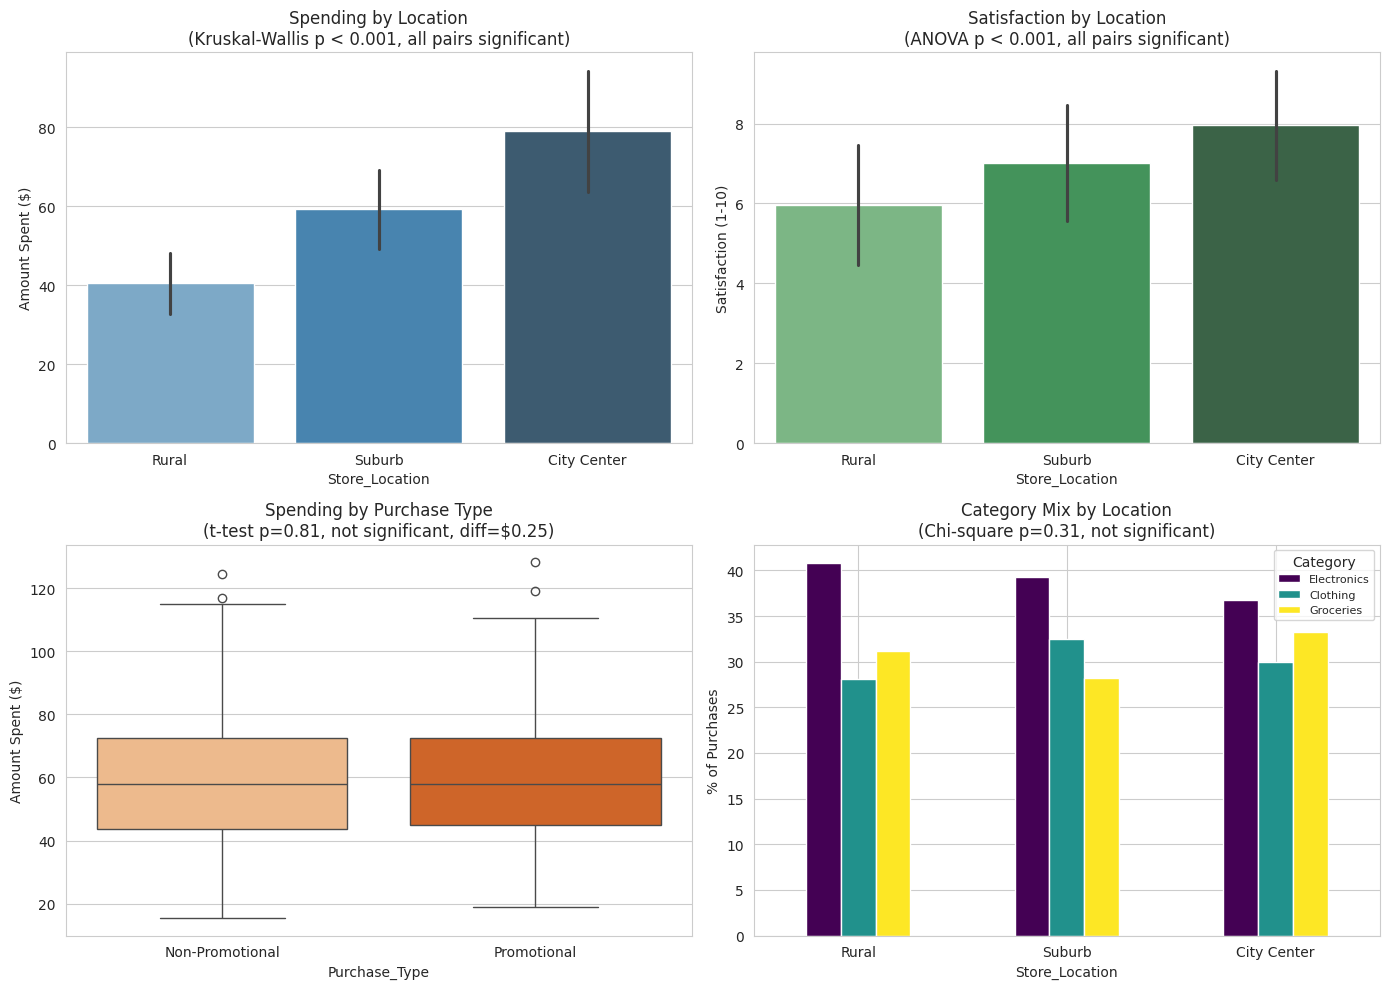

In [ ]:
# Create visualizations to support results - Create new cells as needed
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Spending by location, with MDE-relevant context
order = ['Rural', 'Suburb', 'City Center']
sns.barplot(data=df, x='Store_Location', y='Amount_Spent', order=order,
            errorbar='sd', ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Spending by Location\n(Kruskal-Wallis p < 0.001, all pairs significant)')
axes[0, 0].set_ylabel('Amount Spent ($)')

# Satisfaction by location
sns.barplot(data=df, x='Store_Location', y='Customer_Satisfaction', order=order,
            errorbar='sd', ax=axes[0, 1], palette='Greens_d')
axes[0, 1].set_title('Satisfaction by Location\n(ANOVA p < 0.001, all pairs significant)')
axes[0, 1].set_ylabel('Satisfaction (1-10)')

# Promotional vs non-promotional - near-identical distributions
sns.boxplot(data=df, x='Purchase_Type', y='Amount_Spent', ax=axes[1, 0], palette='Oranges')
axes[1, 0].set_title(f'Spending by Purchase Type\n(t-test p={0.81:.2f}, not significant, diff=$0.25)')
axes[1, 0].set_ylabel('Amount Spent ($)')

# Category mix by location - near-identical bars
ct_pct = pd.crosstab(df['Store_Location'], df['Product_Category'], normalize='index')[['Electronics','Clothing','Groceries']] * 100
ct_pct.loc[order].plot(kind='bar', ax=axes[1, 1], colormap='viridis')
axes[1, 1].set_title('Category Mix by Location\n(Chi-square p=0.31, not significant)')
axes[1, 1].set_ylabel('% of Purchases')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].legend(title='Category', fontsize=8)

plt.tight_layout()
plt.show()

**Reflective Question: Recommendations - Explain the practical implications of the results. What should the company do based on your findings about spending, satisfaction, or product preferences?**

[Write your answer here]

1. **Treat locations as genuinely different markets, not variations on one strategy.** Because both spending and satisfaction differ substantially and consistently by location — with City Center customers spending roughly double what Rural customers spend and reporting meaningfully higher satisfaction — the company should move away from a one-size-fits-all approach to inventory, staffing, and marketing. City Center's combination of high spend and high satisfaction suggests it can support premium inventory and pricing; Rural's lower spend and lower satisfaction warrant investigation into root causes (fewer staff, less selection, longer wait times, etc.) before assuming it's simply a lower-value market.

2. **Prioritize Rural for a customer-experience review.** Rural has the lowest satisfaction by a full point or more against City Center and Suburb, which is large enough (per the 1.0-point MDE) to be actionable. This is worth investigating directly (staffing levels, store condition, product availability) rather than just accepting it as an inherent feature of rural shoppers, since satisfaction — unlike spending — is something operational changes can move.

3. **Re-evaluate the promotional program's ROI.** The data shows promotions are not associated with any meaningful lift in spending ($0.25, far under the $15 MDE, and not statistically significant). Given that promotions come with real margin costs, this is a signal to either redesign the promotional strategy (different discount depth, targeting, or timing) or reallocate that budget elsewhere, rather than continuing to run promotions on the assumption they're driving revenue.

4. **Don't localize product category assortment based on this data.** Since category preference doesn't meaningfully differ by location, there's no evidence here to justify location-specific category mixes (e.g., stocking more Electronics in one location than another). Category-level merchandising decisions should be driven by other factors (overall category profitability, regional supply chain considerations) rather than a location-based preference signal, since this analysis found none.

### Part 5: Reflection

Discuss:
1. The strengths and limitations of your analysis
2. Any assumptions or potential biases in the data
3. Suggestions for additional data collection
4. How this analysis could be improved

**Reflective Question: Explain the importance of experimental design and sufficient sample size in conducting a robust analysis. Identify any limitations in the dataset or analysis (e.g., potential biases, unmeasured variables) and suggest additional data the company could collect to improve future analyses.**

[Write your reflection here]

**Importance of experimental design and sample size.** A well-designed analysis starts with hypotheses and a business-relevant MDE defined *before* looking at results — which this lab did — so that statistical significance can be interpreted against a meaningful bar rather than treated as the finish line on its own. Sample size matters because it directly determines statistical power: with only ~500 observations per location, the analysis would still likely have caught the large location-based effects on spending and satisfaction, but might easily have missed a smaller, still business-relevant effect in the promotional comparison. Conversely, the large sample here (1,500 rows) is also why some assumption tests (like Shapiro-Wilk) flagged "non-normality" that wasn't practically meaningful — a reminder that sample size affects which tests are trustworthy, not just whether an effect will be detected.

**Strengths.** The dataset is clean (no missing values, consistent categories), reasonably balanced across groups, and large enough to support four different statistical tests with good power. Using both a primary test and a robustness-check test (Kruskal-Wallis alongside Welch's/ANOVA sensitivity checks, t-test alongside Mann-Whitney) gives more confidence that conclusions aren't artifacts of one method's assumptions.

**Limitations and potential biases.** This is cross-sectional, observational data — it shows *association*, not causation. We don't know how promotional periods were assigned (if they coincided with holidays, weather, or specific product launches, that could confound the "no promotional lift" finding), or how "location" interacts with store size, local competition, or customer demographics. There's no timestamp, so we can't check for seasonality or trends, and no customer ID, so we can't distinguish new customers from repeat visits or control for individual-level effects (frequent big spenders skewing a location's average). The satisfaction scale's collection method (survey response rate, timing relative to purchase) is also unknown, which could introduce response bias.

**Suggestions for additional data.** To deepen this analysis, the company could collect: (1) a timestamp per transaction, to check for seasonal effects and to properly test *specific* promotional campaigns rather than a pooled "promotional" flag; (2) a customer ID or loyalty number, to distinguish new vs. repeat customers and control for individual spending habits; (3) store-level covariates (store size, staff count, local population/income), to explain *why* locations differ rather than just confirming *that* they differ; (4) the actual promotion type and discount depth, since different promotions likely have very different effects that get averaged away in the current "Promotional vs Non-Promotional" binary; and (5) a satisfaction sub-breakdown (e.g., separate ratings for service, product selection, wait time) to make the Rural satisfaction gap actionable rather than just descriptive.

---
*Note: This cell installs `scikit-posthocs`, which is required for Dunn's post-hoc test used in section 2.4/3.1 above. It has already been installed and used at the top of this notebook — this cell is kept for reference in case the environment needs a fresh install.*

In [7]:
%pip install scikit-posthocs

  Using cached scikit_posthocs-0.16.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached statsmodels-0.15.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.6 kB)
  Using cached patsy-1.0.3-py2.py3-none-any.whl.metadata (3.7 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached wrapt-2.4.0-cp311-cp311-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (7.4 kB)
Using cached scikit_posthocs-0.16.1-py3-none-any.whl (45 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 125.7 kB/s  0:02:23 eta 0:00:010:05:13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-posthocs]5/6 [scikit-posthocs]ls]
Note: you may need to restart the kernel to use updated packages.


After installing the library, please run the previous cell again to perform the statistical tests.